## Understanding the data

On the *train_set.csv* we have more than a million (1'166,835) randomize bookings. Each data point has the following fields:
-   User_id
-   checkin
-   checkout
-   city_id: city_id of the hotel's city (anonymized)
-   hotel_country: Country of the hotel (anonymized)
-   device_class: desktop/mobile/tablet
-   affiliate_id: An anonymized ID of affiliate channels where the booker came from (e.g. direct, some third party referrals, paid search engine, etc.)
-   booker_country: Country from which the reservation was made (anonymized)
-   utrip_id: Unique identifier of a user's trip (a multi-destination booking within the same trip)

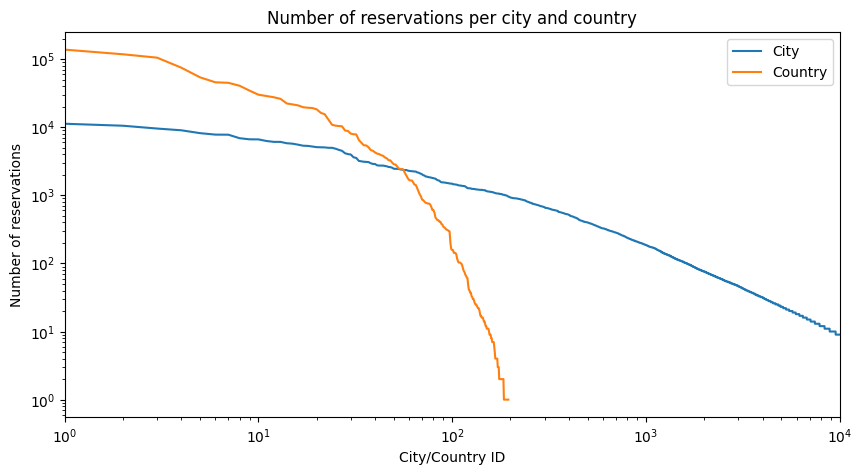

In [2]:
import pandas as pd
from visualize_functions import *
df_raw = pd.read_csv('datasets/train_set.csv')
# convert the date column to datetime and get the duration of each reservation
df_raw = preprocess(df_raw)

# Number of reservations per city and country
yvalues = [df_raw['city_id'].value_counts().values, df_raw['hotel_country'].value_counts().values]
xvalues = [[i for i in range(1, len(yvalues[0]) + 1)], [i for i in range(1, len(yvalues[1]) + 1)]]
labels = ['City', 'Country']
plot_graph(xvalues, yvalues, title='Number of reservations per city and country', y_label='Number of reservations', x_label='City/Country ID', legend=['City', 'Country'], limit_x=(1,10000), type='log')

In [10]:
df_group_trip['duration'].value_counts()

duration
7      26971
6      22664
5      21743
4      21626
8      20813
       ...  
106        1
95         1
70         1
304        1
120        1
Name: count, Length: 81, dtype: int64

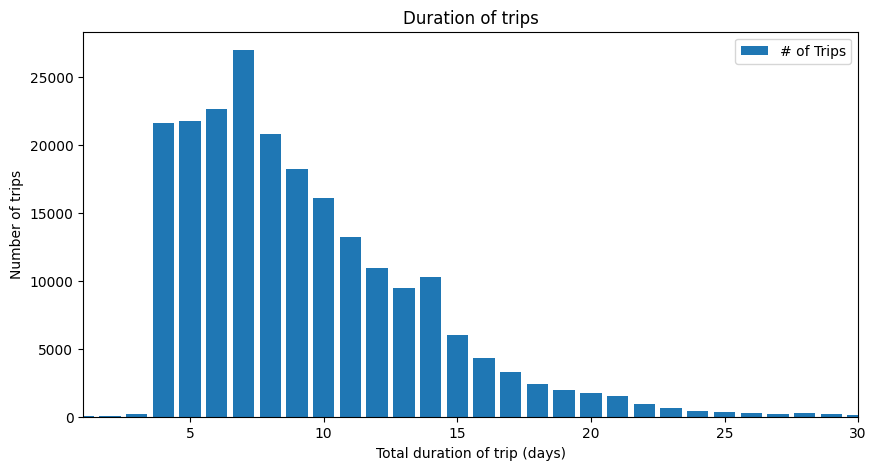

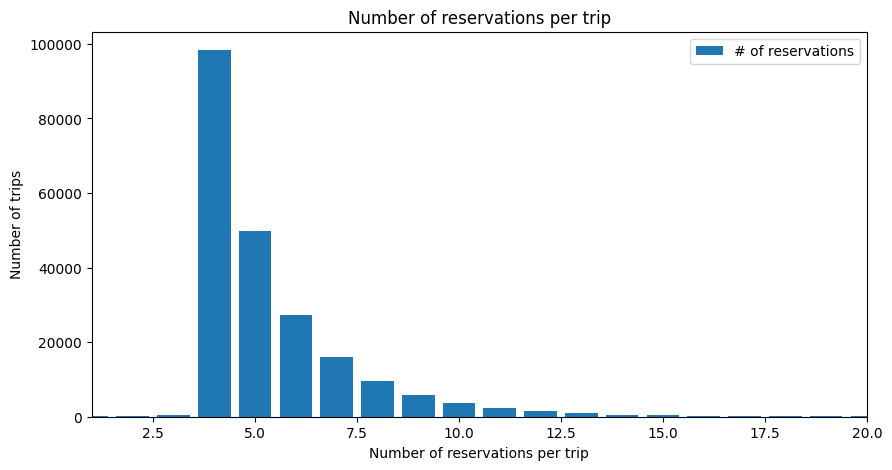

In [26]:
# group by ytrip_id
df_group_trip = df_raw.groupby('utrip_id').agg(
    city_id=('city_id', 'nunique'),
    hotel_country=('hotel_country', 'nunique'),
    duration=('duration', 'sum'),
    checkin=('checkin', 'first'),
    checkout=('checkout', 'last'),
    num_Reservations=('city_id', 'count')
)
yvalues = df_group_trip['duration'].value_counts().values
xvalues = df_group_trip['duration'].value_counts().index
plot_graph(xvalues, yvalues, 
        title='Duration of trips',
        y_label='Number of trips', 
        x_label='Total duration of trip (days)',
        legend=['# of Trips'],
        type='bar',
        limit_x=(1,30)
        )
plot_graph(x_series= df_group_trip['num_Reservations'].value_counts().index, 
        y_series= df_group_trip['num_Reservations'].value_counts().values, 
        title='Number of reservations per trip',
        y_label='Number of trips', 
        x_label='Number of reservations per trip',
        legend=['# of reservations'],
        type='bar',
        limit_x=(1,20)
        )
# get the avg 

In [21]:
# clean the data
print(len(df_group_trip[df_group_trip['num_Reservations'] < 3]))

287
